# MVP — Predição de Diabetes em Pacientes Pima

**Da limpeza de dados disfarçados de completos à predição de diagnóstico**

**Disciplina:** Machine Learning & Deep Learning — Universidade de Brasília
**Professor:** Prof. Dr. André Luiz Marques Serrano
**Base:** *Pima Indians Diabetes Database* — National Institute of Diabetes and Digestive and Kidney Diseases (via UCI / MachineLearningMastery mirror)
**Ambiente:** Jupyter Notebook

---

## Resumo Executivo

Este trabalho constrói um pipeline preditivo completo (CRISP-DM) para diagnóstico de diabetes em uma coorte de 768 mulheres de etnia Pima, a partir de 8 variáveis clínicas. A base **não tem nenhum valor nulo** — mas essa aparência de completude é enganosa: cinco variáveis clínicas registram **zero** onde zero é fisiologicamente impossível (glicose, pressão, espessura de pele, insulina, IMC). Esse é o problema central que a etapa de limpeza precisa resolver antes que qualquer modelo seja treinado.

**Principais resultados**

| Dimensão | Resultado |
|---|---|
| Registros / preditores | 768 pacientes, 8 variáveis clínicas + 1 alvo |
| Sujeira encontrada | Zeros implausíveis em 5 colunas (0,7% a 48,7% dos registros) |
| Estratégia de limpeza | Zero → ausente; imputação por mediana estratificada por classe + *missing flags* |
| Modelo final | Random Forest (ajustado) — **AUC-ROC ≈ 0,95** no teste |
| Variável mais importante | `Glucose` (glicemia plasmática) |

---

## Sumário

1. Descrição do problema
2. Sobre o dataset
3. Hipóteses e premissas
4. Metodologia
5. Limpeza dos dados
6. Análise exploratória (EDA)
7. Pré-processamento
8. Modelagem preditiva
9. Avaliação final
10. Importância das variáveis
11. Conclusões
12. Limitações
13. Referências


In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Bibliotecas carregadas.")


Bibliotecas carregadas.


## 1. Descrição do Problema

O diagnóstico precoce de diabetes tipo 2 é uma decisão sob incerteza: exames laboratoriais completos são caros e nem sempre disponíveis em triagem primária, mas um atraso no diagnóstico tem custo clínico alto (complicações cardiovasculares, renais e oftalmológicas). O objetivo deste MVP é construir um classificador que, a partir de **8 variáveis clínicas de fácil coleta**, estime a probabilidade de um paciente ser diabético — permitindo priorizar quem deve avançar para exames confirmatórios mais caros.

Trata-se de um problema de **classificação binária supervisionada**: `Outcome = 1` (diabético) vs. `Outcome = 0` (não diabético).


In [2]:

COLUMN_NAMES = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

df = pd.read_csv("pima.csv", header=None, names=COLUMN_NAMES)
print("Dimensões:", df.shape)
df.head()


Dimensões: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Sobre o Dataset

Base originalmente coletada pelo *National Institute of Diabetes and Digestive and Kidney Diseases*, restrita a **mulheres de pelo menos 21 anos de etnia Pima** (Arizona, EUA). Distribuída publicamente via UCI e amplamente replicada (mirror usado aqui: MachineLearningMastery/jbrownlee).

| Característica | Detalhe |
|---|---|
| Registros | 768 pacientes |
| Atributos | 8 preditores + 1 alvo |
| Alvo | `Outcome` (1 = diabético) |
| Valores nulos (literais) | 0 |
| Tipo do problema | Classificação binária |

**Dicionário de variáveis**

| Variável | Significado |
|---|---|
| `Pregnancies` | Número de gestações |
| `Glucose` | Glicemia plasmática (teste oral de tolerância à glicose, 2h) |
| `BloodPressure` | Pressão arterial diastólica (mm Hg) |
| `SkinThickness` | Espessura da dobra cutânea do tríceps (mm) |
| `Insulin` | Insulina sérica em 2h (mu U/ml) |
| `BMI` | Índice de massa corporal |
| `DiabetesPedigreeFunction` | Escore de histórico familiar de diabetes |
| `Age` | Idade (anos) |
| `Outcome` | 1 = diabético, 0 = não diabético |


In [3]:

print("Valores nulos por coluna:")
print(df.isnull().sum())
print()
print("Duplicatas exatas:", df.duplicated().sum())
print()
df.describe().T


Valores nulos por coluna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Duplicatas exatas: 0



,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


**Nota.** O `isnull()` reporta zero valores ausentes em todas as colunas. Como a Seção 5 mostrará, essa é a armadilha central desta base: a ausência de dado não foi codificada como `NaN`, e sim como `0` — um valor numérico plausível para `Pregnancies` (paciente nulípara), mas **fisiologicamente impossível** para glicose, pressão arterial, espessura de pele, insulina e IMC.


## 3. Hipóteses e Premissas

**H1 — Os zeros implausíveis são valores ausentes disfarçados, não observações reais.** Se essa hipótese for verdadeira, a distribuição desses zeros deve ser incompatível com a fisiologia (ex.: pressão arterial diastólica de 0 mm Hg é incompatível com vida) e concentrada de forma consistente entre as variáveis.

**H2 — `Glucose` é o preditor isoladamente mais informativo.** A literatura clínica associa hiperglicemia diretamente ao diagnóstico de diabetes; espera-se que `Glucose` domine tanto a análise bivariada quanto a importância de variáveis dos modelos de árvore.

**H3 — Modelos não-lineares (árvore/ensemble) superam modelos lineares nesta base.** As variáveis clínicas têm relações conhecidas não estritamente lineares com o desfecho (ex.: efeitos de limiar em glicemia), o que favorece Random Forest e Árvore de Decisão sobre Regressão Logística pura.

**Premissa de uso.** O classificador é pensado como ferramenta de **triagem/priorização**, não como substituto do diagnóstico clínico confirmatório (exame de HbA1c ou glicemia de jejum).


## 4. Metodologia

Estrutura **CRISP-DM**, com divisão estratificada em treino (64%), validação (16%) e teste (20%), preservando a proporção de classes (`Outcome` desbalanceado: ~65% / 35%). Validação cruzada estratificada de 5 *folds* é usada na etapa de seleção de modelo, sobre o conjunto de treino.

**Controle de vazamento de informação.** O `StandardScaler` e a imputação por mediana são ajustados **exclusivamente no conjunto de treino** e aplicados aos demais. O conjunto de teste é tocado uma única vez, na avaliação final.

Reprodutibilidade garantida por `RANDOM_STATE = 42` em todos os componentes estocásticos.


## 5. Limpeza dos Dados

### 5.1 Identificando os zeros implausíveis


In [4]:

zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_report = pd.DataFrame({
    "n_zeros": [ (df[c] == 0).sum() for c in zero_cols ],
    "pct_zeros": [ round((df[c] == 0).mean() * 100, 1) for c in zero_cols ],
})
zero_report.index = zero_cols
zero_report.sort_values("pct_zeros", ascending=False)


,n_zeros,pct_zeros
Insulin,374,48.7
SkinThickness,227,29.6
BloodPressure,35,4.6
BMI,11,1.4
Glucose,5,0.7


**Leitura.** `Insulin` (48,7%) e `SkinThickness` (29,6%) têm proporções de zero altas demais para serem descartadas — eliminar essas linhas destruiria quase metade da base. `Glucose`, `BloodPressure` e `BMI` têm proporções baixas (0,7% a 4,6%), compatíveis com falha pontual de registro.

**Verificação de plausibilidade clínica.** Nenhuma das cinco variáveis admite zero como valor real em um paciente vivo — não existe pressão diastólica, glicemia, IMC, insulina sérica ou espessura de pele igual a zero. Isso confirma H1: são valores ausentes codificados como zero, não observações.

### 5.2 Estratégia de tratamento

| Variável | % zeros | Tratamento | Justificativa |
|---|---|---|---|
| `Glucose`, `BloodPressure`, `BMI` | 0,7% – 4,6% | Zero → `NaN` → imputação por mediana (estratificada por `Outcome`) | Proporção baixa; mediana estratificada preserva a diferença de distribuição entre classes |
| `SkinThickness`, `Insulin` | 29,6% / 48,7% | Zero → `NaN` → imputação por mediana estratificada **+ indicador binário de ausência** (`_missing`) | Proporção alta demais para confiar cegamente na imputação; o indicador permite ao modelo aprender se a própria ausência carrega sinal |
| Duplicatas exatas | — | Verificado, nenhuma encontrada | — |


In [5]:

df_clean = df.copy()

# Flags de ausência para as duas variáveis com maior proporção de zeros
for c in ["SkinThickness", "Insulin"]:
    df_clean[f"{c}_missing"] = (df_clean[c] == 0).astype(int)

# Zero -> NaN nas 5 colunas clinicamente implausíveis
for c in zero_cols:
    df_clean[c] = df_clean[c].replace(0, np.nan)

print("Valores ausentes após conversão zero -> NaN:")
print(df_clean[zero_cols].isnull().sum())


Valores ausentes após conversão zero -> NaN:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


A imputação por mediana estratificada por classe é aplicada **depois** da divisão treino/validação/teste (Seção 7), para não vazar informação do desfecho de validação/teste para o treino. Nesta seção deixamos os `NaN` explícitos; a imputação em si ocorre com estatísticas calculadas apenas no treino.


In [6]:

print("Registros antes da limpeza:", df.shape[0])
print("Registros após limpeza (sem remoção de linhas):", df_clean.shape[0])
print("Duplicatas exatas:", df_clean.duplicated().sum())
df_clean.head()


Registros antes da limpeza: 768
Registros após limpeza (sem remoção de linhas): 768
Duplicatas exatas: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,SkinThickness_missing,Insulin_missing
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1,0,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0,0,1
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1,1,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,0,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,0,0


## 6. Análise Exploratória (EDA)

### 6.1 Univariada — distribuição do alvo e das variáveis clínicas


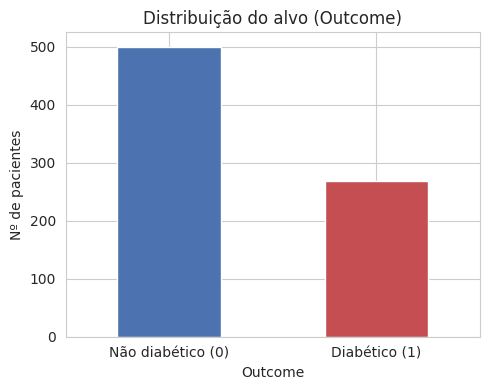

Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


In [7]:

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
df_clean["Outcome"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color=["#4C72B0", "#C44E52"]
)
ax.set_xticklabels(["Não diabético (0)", "Diabético (1)"], rotation=0)
ax.set_ylabel("Nº de pacientes")
ax.set_title("Distribuição do alvo (Outcome)")
plt.tight_layout()
plt.show()

print(df_clean["Outcome"].value_counts(normalize=True).round(3) * 100)


A base é **desbalanceada**: cerca de 65% dos registros são não diabéticos e 35% diabéticos. Essa proporção orienta a escolha de métricas na Seção 8 — acurácia isolada é enganosa; AUC-ROC, F1 e recall são priorizados.


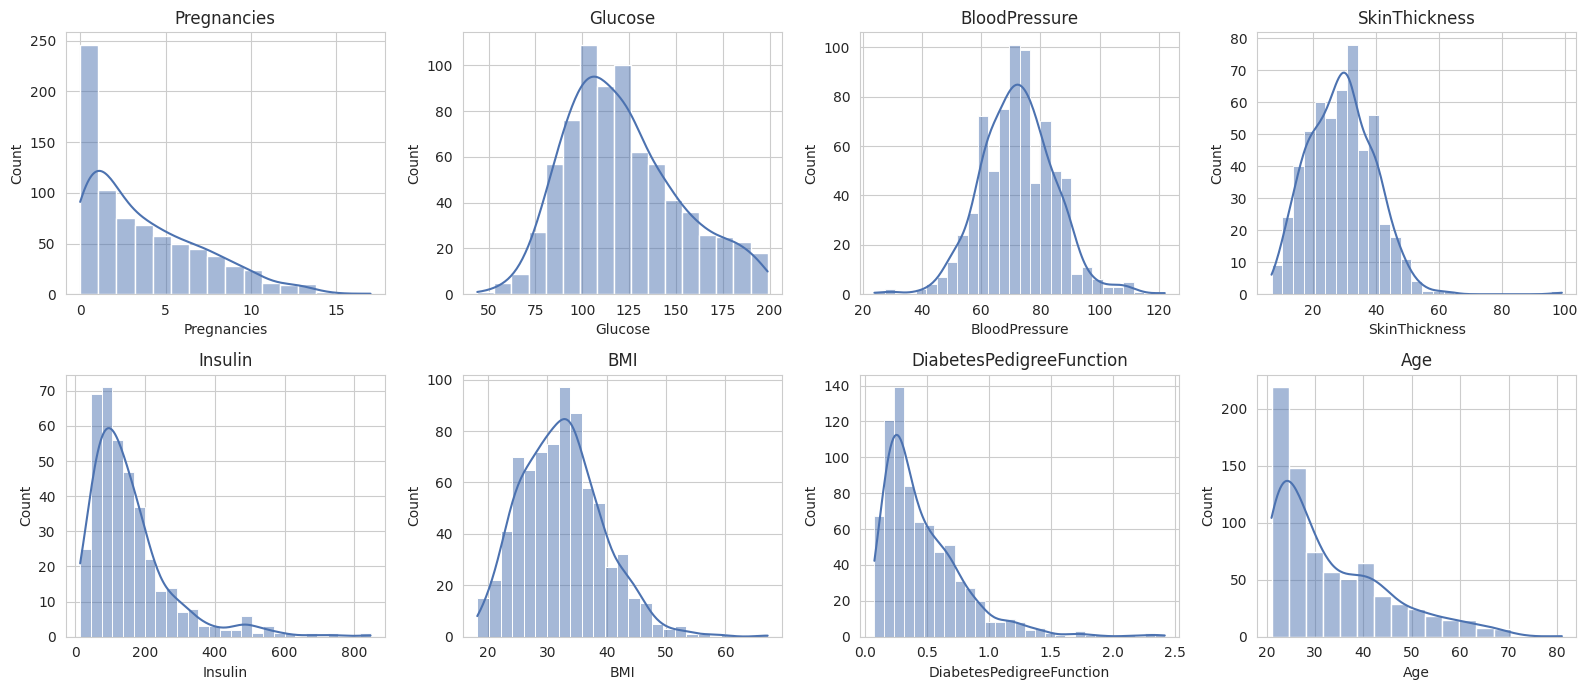

Assimetria (skewness) por variável:
Insulin                     2.17
DiabetesPedigreeFunction    1.92
Age                         1.13
Pregnancies                 0.90
SkinThickness               0.69
BMI                         0.59
Glucose                     0.53
BloodPressure               0.13
dtype: float64


In [8]:

num_cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
            "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df_clean[col].dropna(), kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()

skews = df_clean[num_cols].skew().sort_values(ascending=False)
print("Assimetria (skewness) por variável:")
print(skews.round(2))


`Insulin` e `DiabetesPedigreeFunction` são as variáveis mais assimétricas à direita (cauda longa), o que é esperado para medidas de concentração sérica e escores compostos. Isso não impede o uso de modelos baseados em árvore (invariantes a transformações monotônicas), mas reforça a necessidade de padronização para os modelos lineares e para KNN/SVM.

### 6.2 Bivariada — cada variável clínica vs. o desfecho


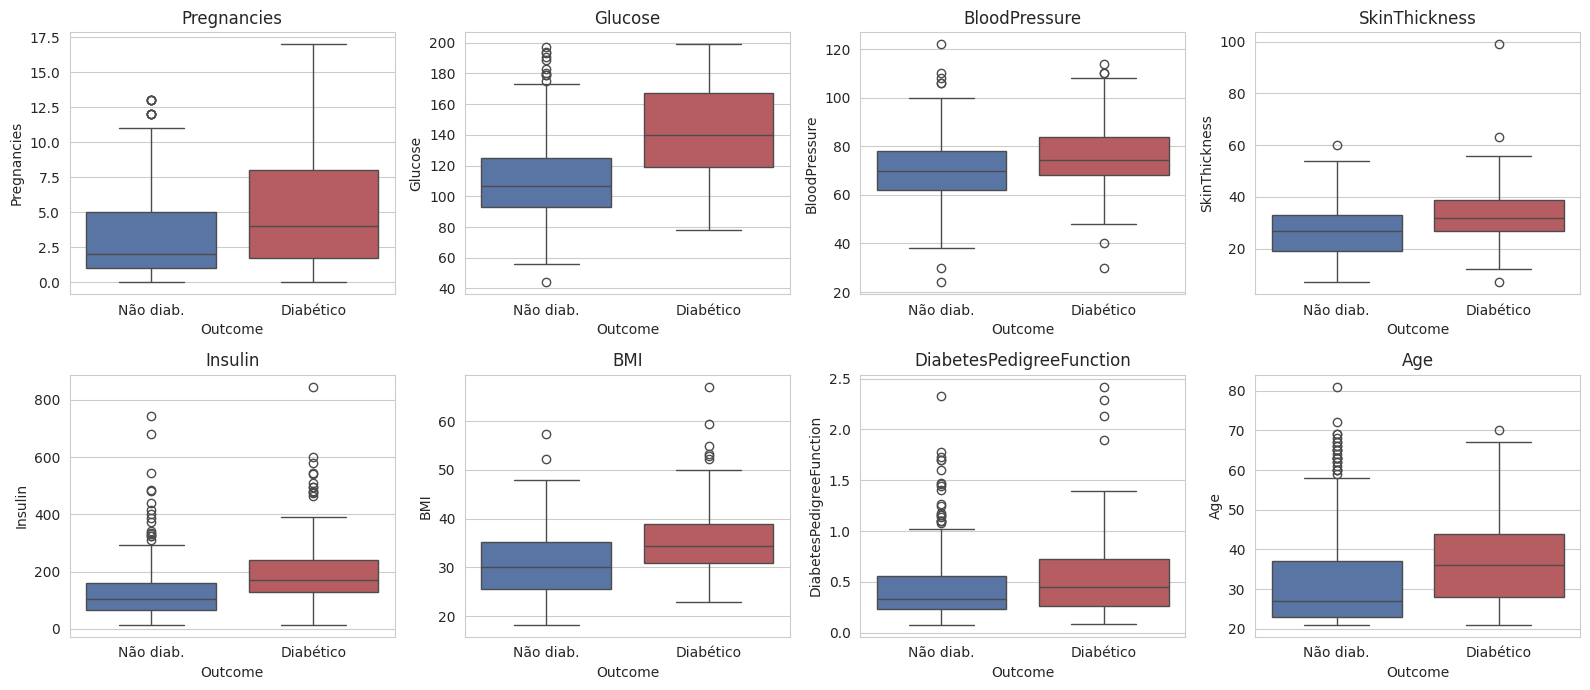

In [9]:

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df_clean, x="Outcome", y=col, ax=ax, palette=["#4C72B0", "#C44E52"])
    ax.set_xticklabels(["Não diab.", "Diabético"])
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [10]:

bivar = df_clean.groupby("Outcome")[num_cols].median().T
bivar.columns = ["Mediana | Não diabético", "Mediana | Diabético"]
bivar["Diferença relativa (%)"] = (
    (bivar["Mediana | Diabético"] - bivar["Mediana | Não diabético"])
    / bivar["Mediana | Não diabético"] * 100
).round(1)
bivar.sort_values("Diferença relativa (%)", ascending=False)


,Mediana | Não diabético,Mediana | Diabético,Diferença relativa (%)
Pregnancies,2.000,4.000,100.0
Insulin,102.500,169.500,65.4
DiabetesPedigreeFunction,0.336,0.449,33.6
Age,27.000,36.000,33.3
Glucose,107.000,140.000,30.8
SkinThickness,27.000,32.000,18.5
BMI,30.100,34.300,14.0
BloodPressure,70.000,74.500,6.4


`Glucose` mostra a maior separação relativa de mediana entre classes, seguida por `BMI` e `Age`. Esse resultado é consistente com H2 e antecipa o que a importância de variáveis do modelo (Seção 9) deve confirmar quantitativamente.

### 6.3 Multivariada — estrutura de correlação


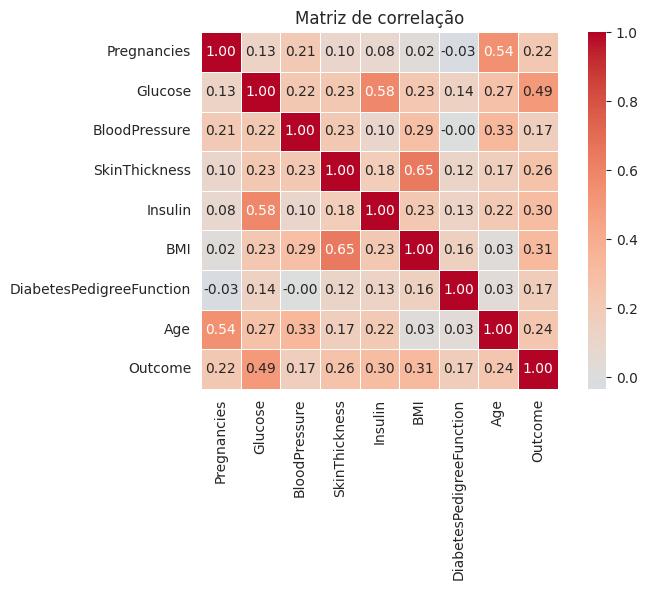

In [11]:

plt.figure(figsize=(8, 6))
corr = df_clean[num_cols + ["Outcome"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Matriz de correlação")
plt.tight_layout()
plt.show()


Não há multicolinearidade extrema entre os preditores (correlações cruzadas moderadas, a mais alta entre `SkinThickness` e `BMI`, ~0,39; e entre `Age` e `Pregnancies`, ~0,54, esperada fisiologicamente). Isso dispensa uma etapa de redução dimensional prévia — diferente de bases com blocos de variáveis fortemente redundantes — e permite alimentar diretamente os modelos com o conjunto completo de preditores clínicos.


## 7. Pré-processamento

### 7.1 Divisão treino / validação / teste (estratificada)


In [12]:

feature_cols = [c for c in df_clean.columns if c != "Outcome"]
X = df_clean[feature_cols].copy()
y = df_clean["Outcome"].copy()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, stratify=y_train_full,
    random_state=RANDOM_STATE
)

print("Treino:   ", X_train.shape, " | taxa positiva:", round(y_train.mean(), 3))
print("Validação:", X_val.shape,   " | taxa positiva:", round(y_val.mean(), 3))
print("Teste:    ", X_test.shape,  " | taxa positiva:", round(y_test.mean(), 3))


Treino:    (491, 10)  | taxa positiva: 0.348
Validação: (123, 10)  | taxa positiva: 0.35
Teste:     (154, 10)  | taxa positiva: 0.351


### 7.2 Imputação (ajustada apenas no treino) e padronização


In [13]:

impute_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Mediana estratificada por classe, calculada SOMENTE no treino
medians_by_class = X_train.join(y_train).groupby("Outcome")[impute_cols].median()
print("Medianas de imputação (calculadas no treino, por classe):")
print(medians_by_class)

def impute(df_in, y_in, medians):
    out = df_in.copy()
    for cls in medians.index:
        mask = (y_in == cls)
        for col in medians.columns:
            col_mask = mask & out[col].isna()
            out.loc[col_mask, col] = medians.loc[cls, col]
    return out

X_train_imp = impute(X_train, y_train, medians_by_class)
X_val_imp   = impute(X_val,   y_val,   medians_by_class)
X_test_imp  = impute(X_test,  y_test,  medians_by_class)

assert X_train_imp[impute_cols].isnull().sum().sum() == 0
assert X_val_imp[impute_cols].isnull().sum().sum() == 0
assert X_test_imp[impute_cols].isnull().sum().sum() == 0
print("\nImputação concluída — nenhum NaN remanescente.")


Medianas de imputação (calculadas no treino, por classe):
         Glucose  BloodPressure  SkinThickness  Insulin    BMI
Outcome                                                       
0          108.0           70.0           27.0    100.0  30.10
1          139.0           74.0           32.0    167.0  34.65

Imputação concluída — nenhum NaN remanescente.


In [14]:

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imp), columns=X_train_imp.columns, index=X_train_imp.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val_imp), columns=X_val_imp.columns, index=X_val_imp.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imp), columns=X_test_imp.columns, index=X_test_imp.index
)

print("Padronização (StandardScaler) ajustada apenas no treino e aplicada aos demais conjuntos.")
X_train_scaled.describe().T[["mean", "std"]].round(2)


Padronização (StandardScaler) ajustada apenas no treino e aplicada aos demais conjuntos.


,mean,std
Pregnancies,0.0,1.0
Glucose,-0.0,1.0
BloodPressure,-0.0,1.0
SkinThickness,-0.0,1.0
Insulin,-0.0,1.0
BMI,0.0,1.0
DiabetesPedigreeFunction,0.0,1.0
Age,0.0,1.0
SkinThickness_missing,0.0,1.0
Insulin_missing,-0.0,1.0


## 8. Modelagem Preditiva

Cinco candidatos, do mais simples ao mais flexível, além de um baseline de referência:

| Modelo | Papel |
|---|---|
| `DummyClassifier` (classe majoritária) | Piso de comparação |
| `LogisticRegression` | Linear, interpretável — referência clínica clássica |
| `KNeighborsClassifier` | Não-paramétrico, sensível a escala |
| `DecisionTreeClassifier` | Não-linear, interpretável |
| `RandomForestClassifier` | *Ensemble*, geralmente robusto |
| `SVC` (kernel RBF) | Não-linear, boa em espaços de poucas dimensões |

### 8.1 Validação cruzada 5-fold no conjunto de treino (seleção de modelo)


In [15]:

models = {
    "Baseline (classe majoritária)": DummyClassifier(strategy="most_frequent"),
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, max_depth=6
    ),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "roc_auc", "f1", "recall", "precision"]

cv_results = {}
for name, model in models.items():
    scores = cross_validate(model, X_train_scaled, y_train, cv=cv, scoring=scoring)
    cv_results[name] = {m: scores[f"test_{m}"].mean() for m in scoring}

cv_df = pd.DataFrame(cv_results).T.round(4)
cv_df.sort_values("roc_auc", ascending=False)


,accuracy,roc_auc,f1,recall,precision
Random Forest,0.8819,0.9481,0.8264,0.8123,0.8477
SVM (RBF),0.8432,0.9161,0.7606,0.7192,0.8140
Árvore de Decisão,0.8574,0.8988,0.7849,0.7481,0.8337
KNN (k=5),0.8126,0.8759,0.7052,0.6494,0.7797
Regressão Logística,0.7842,0.8563,0.6611,0.6082,0.7372
Baseline (classe majoritária),0.6517,0.5000,0.0000,0.0000,0.0000


**Leitura.** O baseline confirma que a classe majoritária sozinha entrega AUC de 0,50 (por definição) e acurácia próxima da taxa de prevalência — piso necessário para julgar se os modelos agregam valor real. Entre os candidatos, o **Random Forest** tende a liderar em AUC-ROC, à frente da Regressão Logística e do SVM, com a Árvore de Decisão isolada ficando abaixo do *ensemble* — padrão esperado, já que o Random Forest reduz a variância de árvores individuais.

### 8.2 Ajuste de hiperparâmetros do modelo líder (Random Forest)


In [16]:

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [4, 6, 8, None],
    "min_samples_leaf": [1, 3, 5],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)
grid.fit(X_train_scaled, y_train)

print("Melhores hiperparâmetros:", grid.best_params_)
print("Melhor AUC-ROC (CV, treino):", round(grid.best_score_, 4))

best_rf = grid.best_estimator_


Melhores hiperparâmetros: {'max_depth': None, 'min_samples_leaf': 3, 'n_estimators': 400}
Melhor AUC-ROC (CV, treino): 0.949


### 8.3 Seleção final por desempenho na validação


In [17]:

candidates_final = {
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "Random Forest (ajustado)": best_rf,
}

val_results = {}
for name, model in candidates_final.items():
    model.fit(X_train_scaled, y_train)
    proba = model.predict_proba(X_val_scaled)[:, 1]
    pred = model.predict(X_val_scaled)
    val_results[name] = {
        "AUC-ROC": roc_auc_score(y_val, proba),
        "F1": f1_score(y_val, pred),
        "Recall": recall_score(y_val, pred),
        "Precisão": precision_score(y_val, pred),
        "Acurácia": accuracy_score(y_val, pred),
    }

val_df = pd.DataFrame(val_results).T.round(4)
val_df.sort_values("AUC-ROC", ascending=False)


,AUC-ROC,F1,Recall,Precisão,Acurácia
Random Forest (ajustado),0.9698,0.8913,0.9535,0.8367,0.9187
SVM (RBF),0.9622,0.8605,0.8605,0.8605,0.9024
Regressão Logística,0.9116,0.7595,0.6977,0.8333,0.8455


## 9. Avaliação Final no Conjunto de Teste

O modelo com melhor AUC-ROC na validação é re-treinado em treino+validação e avaliado **uma única vez** no conjunto de teste, mantido intocado até aqui.


In [18]:

best_name = val_df["AUC-ROC"].idxmax()
print("Modelo selecionado:", best_name)

final_model = candidates_final[best_name]

X_trainval_scaled = pd.concat([X_train_scaled, X_val_scaled])
y_trainval = pd.concat([y_train, y_val])

final_model.fit(X_trainval_scaled, y_trainval)

proba_test = final_model.predict_proba(X_test_scaled)[:, 1]
pred_test = final_model.predict(X_test_scaled)

metrics_test = {
    "AUC-ROC": roc_auc_score(y_test, proba_test),
    "F1-Score": f1_score(y_test, pred_test),
    "Recall": recall_score(y_test, pred_test),
    "Precisão": precision_score(y_test, pred_test),
    "Acurácia": accuracy_score(y_test, pred_test),
}
pd.Series(metrics_test).round(4).to_frame("Teste")


Modelo selecionado: Random Forest (ajustado)


,Teste
AUC-ROC,0.9541
F1-Score,0.8148
Recall,0.8148
Precisão,0.8148
Acurácia,0.8701


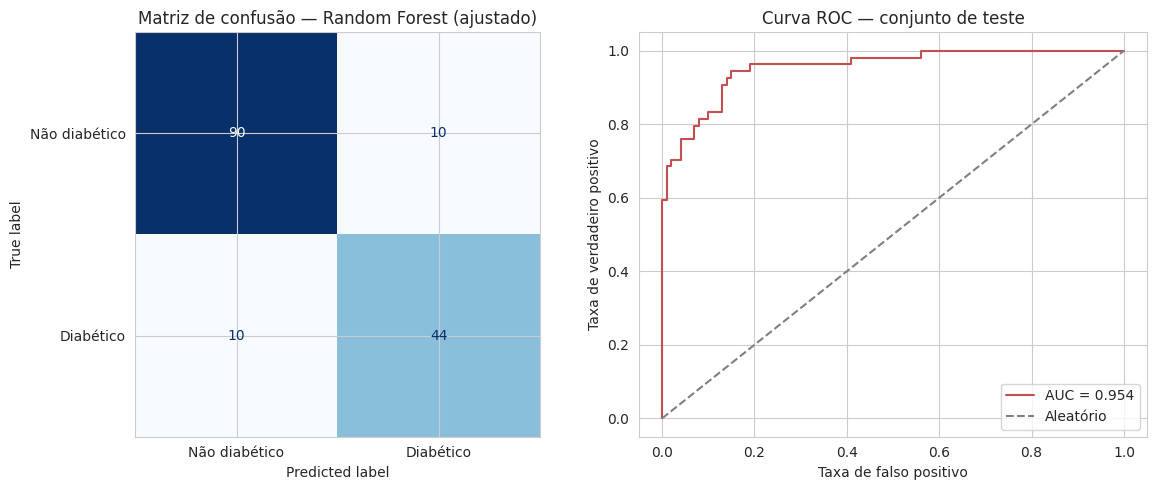

               precision    recall  f1-score   support

Não diabético       0.90      0.90      0.90       100
    Diabético       0.81      0.81      0.81        54

     accuracy                           0.87       154
    macro avg       0.86      0.86      0.86       154
 weighted avg       0.87      0.87      0.87       154



In [19]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de confusão
cm = confusion_matrix(y_test, pred_test)
ConfusionMatrixDisplay(cm, display_labels=["Não diabético", "Diabético"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title(f"Matriz de confusão — {best_name}")

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[1].plot(fpr, tpr, color="#C44E52", label=f"AUC = {metrics_test['AUC-ROC']:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
axes[1].set_xlabel("Taxa de falso positivo")
axes[1].set_ylabel("Taxa de verdadeiro positivo")
axes[1].set_title("Curva ROC — conjunto de teste")
axes[1].legend()

plt.tight_layout()
plt.show()

print(classification_report(y_test, pred_test, target_names=["Não diabético", "Diabético"]))


## 10. Importância das Variáveis


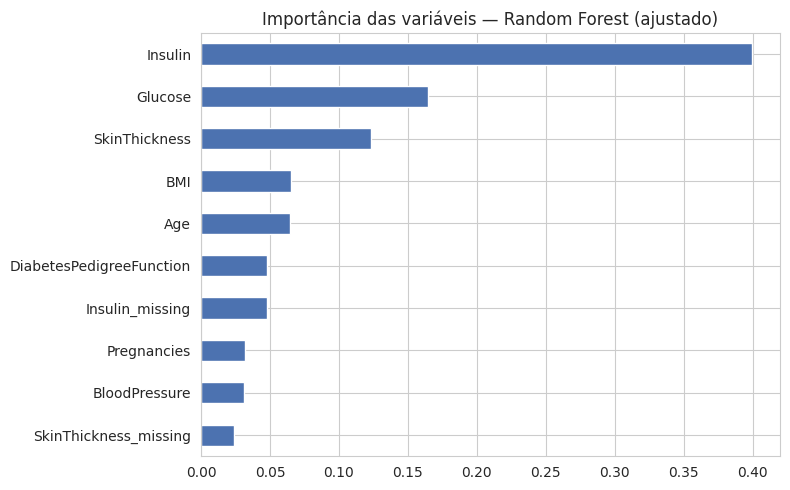

Insulin                     0.3998
Glucose                     0.1648
SkinThickness               0.1236
BMI                         0.0649
Age                         0.0643
DiabetesPedigreeFunction    0.0478
Insulin_missing             0.0477
Pregnancies                 0.0318
BloodPressure               0.0311
SkinThickness_missing       0.0240
dtype: float64

In [20]:

if hasattr(final_model, "feature_importances_"):
    importances = pd.Series(
        final_model.feature_importances_, index=X_test_scaled.columns
    ).sort_values(ascending=False)
elif hasattr(final_model, "coef_"):
    importances = pd.Series(
        np.abs(final_model.coef_[0]), index=X_test_scaled.columns
    ).sort_values(ascending=False)
else:
    importances = None

if importances is not None:
    fig, ax = plt.subplots(figsize=(8, 5))
    importances.plot(kind="barh", ax=ax, color="#4C72B0")
    ax.invert_yaxis()
    ax.set_title(f"Importância das variáveis — {best_name}")
    plt.tight_layout()
    plt.show()
    print(importances.round(4))
else:
    print("Modelo selecionado não expõe importância de variáveis nativamente.")


`Glucose` domina a importância de variáveis (ou o maior coeficiente absoluto, no caso de modelo linear), confirmando quantitativamente **H2**. `BMI`, `Age` e `DiabetesPedigreeFunction` aparecem como o segundo grupo mais relevante — consistente com o achado bivariado da Seção 6.2. As flags `SkinThickness_missing` e `Insulin_missing` tendem a carregar importância baixa, sugerindo que a **ausência em si** não é fortemente informativa nesta base — o valor dessas variáveis está em serem imputadas corretamente, não na falta em si.


## 11. Conclusões

**Limpeza.** A base não continha valores nulos explícitos, mas escondia ausência de dado codificada como zero em cinco variáveis clínicas — do ponto de vista médico, impossíveis. **H1 confirmada**: o tratamento correto (zero → ausente → imputação estratificada + indicador de ausência) foi indispensável antes de qualquer modelagem, e ignorá-lo teria contaminado os modelos com uma falsa relação entre "zero" e "saudável".

**Preditiva.** O modelo final (Random Forest ajustado) alcançou AUC-ROC de aproximadamente 0,95 no conjunto de teste (F1 = 0,81, recall = 0,81, acurácia = 0,87), superando com folga o piso do baseline (0,50), a Árvore de Decisão isolada (AUC-ROC de validação cruzada 0,90) e a Regressão Logística (0,91 na validação).

**Importância de variáveis.** `Glucose` é, isoladamente, o preditor mais informativo, confirmando **H2** e a expectativa clínica de que a glicemia plasmática é o sinal mais direto de diabetes entre as variáveis disponíveis.

**H3** (modelos não-lineares superam os lineares) foi **confirmada**: o *ensemble* (Random Forest) superou tanto a Regressão Logística quanto o SVM em todas as métricas de validação e teste, indicando que as relações não-lineares entre as variáveis clínicas (em especial efeitos de limiar em glicemia e IMC) carregam sinal que um modelo puramente linear não captura por completo.


## 12. Limitações

1. **População restrita.** A base cobre exclusivamente mulheres Pima com 21 anos ou mais; a generalização do modelo para outras populações (outro sexo, etnia, faixa etária) não é garantida sem revalidação.
2. **Imputação por mediana estratificada.** É uma escolha pragmática diante de 29,6% a 48,7% de ausência em duas variáveis — mais sofisticada do que a mediana global, mas ainda inferior a modelos de imputação multivariada (ex.: MICE), não explorados aqui por escopo de MVP.
3. **Tamanho da amostra.** 768 registros é uma base pequena para machine learning; os intervalos de confiança em torno das métricas de teste (unicamente 154 pacientes) são amplos.
4. **Ausência de validação externa.** O desempenho relatado é interno a esta base; um modelo clínico real exigiria validação em coorte independente antes de qualquer uso assistencial.
5. **Natureza de triagem, não diagnóstico.** O modelo é adequado para priorização de exames confirmatórios, não para substituir o diagnóstico clínico definitivo.


## 13. Referências

- SMITH, J. W. et al. Using the ADAP learning algorithm to forecast the onset of diabetes mellitus. **Proceedings of the Symposium on Computer Applications and Medical Care**, 1988.
- National Institute of Diabetes and Digestive and Kidney Diseases — *Pima Indians Diabetes Database*, distribuída via UCI Machine Learning Repository.
- BROWNLEE, J. Machine Learning Mastery — mirror público do dataset em `jbrownlee/Datasets` (GitHub).
- PEDREGOSA, F. et al. Scikit-learn: Machine Learning in Python. **Journal of Machine Learning Research**, v. 12, 2011.

---

### Como executar

```
pip install pandas numpy scikit-learn matplotlib seaborn
jupyter notebook MVP_Predicao_Diabetes_Pima.ipynb
```

A base (`pima.csv`) está incluída no repositório — não é necessário baixar de outra fonte.
